# **Experiments #3 — POA with Fully-Random Initialization**

## Objectives
- Prove which scheduling assignment order is best
- Prove teacher–lab-expertise scheduling is more effective
- Measure % of teachers not teaching in their lab domain
- Prove computational environment affects solution quality

## Key Correction (v3)
| | Previous (wrong) | This notebook (correct) |
|---|---|---|
| Units scheduled | 113 (collapsed) | **725** (one per row) |
| Source | `drop_duplicates(course×prodi)` | Every row in `mk_dsi_genap_praktikum.csv` |
| Each row represents | One *course* | One **class section** with teacher pre-assigned |
| Genes per unit | 4 `[teacher,room,day,slot]` | **3** `[room,day,slot]` |
| Solution vector | 448 genes | **2175 genes** |

---

# **Data Setup**

## *Import Used Library*

In [3]:
# ─────────────────────────────────────────────────────────────
# Cell 1 ▸ Import Used Libraries
# ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import random
import time
import math
import warnings
from collections import defaultdict
from itertools import combinations
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore")
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
random.seed(GLOBAL_SEED)

print("Libraries loaded.")
print(f"NumPy  : {np.__version__}")
print(f"Pandas : {pd.__version__}")


Libraries loaded.
NumPy  : 1.26.4
Pandas : 2.1.4


## *Dataset Understanding*

Courses, teachers, laboratories, rooms, timeslots

In [4]:
# ─────────────────────────────────────────────────────────────
# Cell 2 ▸ Dataset Understanding
# ─────────────────────────────────────────────────────────────
#
# SOURCE FILES
# ─────────────────────────────────────────────────────────────
# mk_dsi_genap_praktikum.csv  ← PRIMARY scheduling dataset (Genap)
#   Each row = ONE class section with teacher ALREADY assigned
#   course_name contains "- Praktikum" → practicum session
#   course_name without "- Praktikum"  → theory session
#
# mk_dsi.csv          ← full multi-semester reference (all semesters)
# teacher_lab_expertise.csv  ← teacher → laboratory mapping
# rooms.csv           ← theory rooms
# practicum_rooms.csv ← practicum (lab) rooms
# days.csv            ← days of week
# ─────────────────────────────────────────────────────────────

df_raw       = pd.read_csv("/home/emery/Documents/Scheduling_Puma_Optimizer/app/assets/data/mk_dsi_genap_praktikum.csv")
df_all_sem   = pd.read_csv("/home/emery/Documents/Scheduling_Puma_Optimizer/app/assets/data/mk_dsi.csv")
df_lab_exp   = pd.read_csv("/home/emery/Documents/Scheduling_Puma_Optimizer/app/assets/data/teacher_lab_expertise.csv")
df_rooms_all = pd.read_csv("/home/emery/Documents/Scheduling_Puma_Optimizer/app/assets/data/rooms.csv")
df_prac_rooms= pd.read_csv("/home/emery/Documents/Scheduling_Puma_Optimizer/app/assets/data/practicum_rooms.csv")

# Global constants
DAYS          = ["Monday","Tuesday","Wednesday","Thursday","Friday"]
SLOTS_PER_DAY = 13        # 13 slots × 50 min per day
SLOT_DURATION = 50        # minutes per slot
START_HOUR    = 7         # 07:00 first slot

slot_labels = [
    f"{(START_HOUR*60 + i*SLOT_DURATION)//60:02d}:{(START_HOUR*60 + i*SLOT_DURATION)%60:02d}"
    for i in range(SLOTS_PER_DAY)
]

print("=" * 65)
print("PRIMARY DATASET  (mk_dsi_genap_praktikum.csv)")
print("=" * 65)
print(df_raw.head(6).to_string(index=False))
print(f"\nRows            : {len(df_raw)}")
print(f"Unique course_id: {df_raw['course_id'].nunique()}")
print(f"Unique prodi    : {df_raw['prodi'].nunique()}")

df_raw["teacher_id"] = df_raw["teacher_id"].astype(str)
df_raw["is_practicum"] = df_raw["course_name"].str.contains("Praktikum", na=False)
print(f"Theory rows     : {(~df_raw['is_practicum']).sum()}")
print(f"Practicum rows  : {df_raw['is_practicum'].sum()}")

print("\nProdi breakdown:")
for prodi, grp in df_raw.groupby("prodi"):
    th = (~grp["is_practicum"]).sum()
    pr = grp["is_practicum"].sum()
    print(f"  {prodi:40s}: {th:3d} theory + {pr:3d} practicum = {th+pr:3d}")

print("\nSKS distribution:", df_raw["sks"].value_counts().sort_index().to_dict())

print("\n" + "=" * 65)
print("REFERENCE DATASET  (mk_dsi.csv — all semesters)")
print("=" * 65)
for sem, cnt in df_all_sem["course_genap_ganjil"].value_counts().items():
    print(f"  {sem:15s}: {cnt} rows")

print("\n" + "=" * 65)
print("TEACHER LAB EXPERTISE")
print("=" * 65)
df_lab_exp["lecturer_id"] = df_lab_exp["lecturer_id"].astype(str)
print(df_lab_exp.head(8).to_string(index=False))
print("\nLab distribution:", df_lab_exp["lab"].value_counts().to_dict())

print("\n" + "=" * 65)
print("ROOMS")
print("=" * 65)
print(f"Theory rooms    : {len(df_rooms_all)}")
print(f"Practicum rooms : {len(df_prac_rooms)}")
print(f"Slot times      : {slot_labels}")


PRIMARY DATASET  (mk_dsi_genap_praktikum.csv)
course_id             course_name               prodi  sks  course_time_minute course_type  teacher_priority    teacher_position teacher_id
 CSD60706 Administrasi Basis Data Teknologi Informasi    3                 100     Pilihan                 1            Pengampu         75
 CSD60706 Administrasi Basis Data Teknologi Informasi    3                 100     Pilihan                 1            Pengampu         91
 CSD60706 Administrasi Basis Data Teknologi Informasi    3                 100     Pilihan                 1 Pengelola, Pengampu        102
 CSD60706 Administrasi Basis Data Teknologi Informasi    3                 100     Pilihan                 1            Pengampu     TBA_47
 CIT62015     Administrasi Sistem Teknologi Informasi    4                 100       Wajib                 2            Pengampu         65
 CIT62015     Administrasi Sistem Teknologi Informasi    4                 100       Wajib                 1      

## *Splitting Course Ganjil — Genap*

In [5]:
# ─────────────────────────────────────────────────────────────
# Cell 3 ▸ Splitting Course Ganjil — Genap
#
# The PRIMARY scheduling file (mk_dsi_genap_praktikum.csv)
# already contains ONLY the Genap semester.
# This cell demonstrates the distribution from the reference
# file (mk_dsi.csv) for context.
# ─────────────────────────────────────────────────────────────

GENAP_VALUES = ["Genap", "Ganjil/Genap"]

df_all_sem["teacher_id"] = df_all_sem["teacher_id"].astype(str)
df_ganjil = df_all_sem[df_all_sem["course_genap_ganjil"] == "Ganjil"]
df_genap  = df_all_sem[df_all_sem["course_genap_ganjil"].isin(GENAP_VALUES)]

print("=" * 65)
print("SEMESTER DISTRIBUTION  (mk_dsi.csv reference)")
print("=" * 65)
print(f"Total rows         : {len(df_all_sem)}")
print(f"Ganjil rows        : {len(df_ganjil)}")
print(f"Genap rows         : {len(df_genap)}")
print(f"  Genap-only       : {len(df_all_sem[df_all_sem['course_genap_ganjil']=='Genap'])}")
print(f"  Ganjil/Genap     : {len(df_all_sem[df_all_sem['course_genap_ganjil']=='Ganjil/Genap'])}")

print("\n" + "─" * 65)
print("KEY INSIGHT: What each row actually represents")
print("─" * 65)
ex = df_genap[
    (df_genap["course_id"]=="COM60024") &
    (df_genap["prodi"]=="Sistem Informasi")
][["course_name","prodi","teacher_priority","teacher_position","teacher_id"]]
print("Example — COM60024 Pemrograman Lanjut (Sistem Informasi):")
print(ex.to_string(index=False))
print(f"\n→ {len(ex)} rows = {len(ex)} PARALLEL CLASS SECTIONS, each needs its own")
print("  room + day + timeslot assignment.")
print("  drop_duplicates() would collapse these to 1 unit — WRONG!")

print("\n>>> Working dataset: mk_dsi_genap_praktikum.csv")
print(f"    725 rows = 725 class sections to schedule")


SEMESTER DISTRIBUTION  (mk_dsi.csv reference)
Total rows         : 846
Ganjil rows        : 244
Genap rows         : 602
  Genap-only       : 462
  Ganjil/Genap     : 140

─────────────────────────────────────────────────────────────────
KEY INSIGHT: What each row actually represents
─────────────────────────────────────────────────────────────────
Example — COM60024 Pemrograman Lanjut (Sistem Informasi):
       course_name            prodi  teacher_priority                           teacher_position teacher_id
Pemrograman Lanjut Sistem Informasi                 1                                   Pengampu          1
Pemrograman Lanjut Sistem Informasi                 1                        Pengelola, Pengampu          4
Pemrograman Lanjut Sistem Informasi                 1 Koordinator Pengelola, Pengelola, Pengampu         16
Pemrograman Lanjut Sistem Informasi                 1 Koordinator Pengelola, Pengelola, Pengampu         20
Pemrograman Lanjut Sistem Informasi                

## *Splitting Selected Courses by Theory and Practicum*

In [6]:
# ─────────────────────────────────────────────────────────────
# Cell 4 ▸ Splitting: Theory vs Practicum sessions
#
# Detection: course_name containing "- Praktikum" → practicum
# ─────────────────────────────────────────────────────────────

# Drop the 3 exact duplicates (same course×prodi×teacher×name)
df_schedule = (
    df_raw
    .drop_duplicates(["course_id","prodi","teacher_id","course_name"])
    .reset_index(drop=True)
    .copy()
)

df_theory_sessions = df_schedule[~df_schedule["is_practicum"]].copy()
df_prac_sessions   = df_schedule[ df_schedule["is_practicum"]].copy()

print("=" * 65)
print("THEORY vs PRACTICUM SESSIONS")
print("=" * 65)
print(f"After removing {len(df_raw)-len(df_schedule)} duplicates:")
print(f"  Total sessions  : {len(df_schedule)}")
print(f"  Theory sessions : {len(df_theory_sessions)}")
print(f"  Practicum sess. : {len(df_prac_sessions)}")

print("\nPracticum sessions (all):")
print(df_prac_sessions[["course_id","course_name","prodi","sks","teacher_id"]].to_string(index=False))


THEORY vs PRACTICUM SESSIONS
After removing 3 duplicates:
  Total sessions  : 722
  Theory sessions : 602
  Practicum sess. : 120

Practicum sessions (all):
course_id                                            course_name                          prodi  sks teacher_id
 CIT62015                        Administrasi Sistem - Praktikum            Teknologi Informasi    4         65
 CIT62015                        Administrasi Sistem - Praktikum            Teknologi Informasi    4         75
 CIT62015                        Administrasi Sistem - Praktikum            Teknologi Informasi    4        104
 CIE61208                                 Basis Data - Praktikum Pendidikan Teknologi Informasi    3          4
 CIS62125                        GeoInformasi Lanjut - Praktikum               Sistem Informasi    3         11
 CIS62125                        GeoInformasi Lanjut - Praktikum               Sistem Informasi    3         87
 CSD60713                           Jaringan Terapan - Prak

## *Generated Course Time based on SKS*

In [7]:
# ─────────────────────────────────────────────────────────────
# Cell 5 ▸ Generated Course Time based on SKS
#   SKS <= 3  →  100 min  =  2 consecutive slots
#   SKS >= 4  →  150 min  =  3 consecutive slots
# ─────────────────────────────────────────────────────────────

def sks_to_slots(sks: int) -> int:
    return 2 if sks <= 3 else 3

df_schedule["slots_needed"]   = df_schedule["sks"].apply(sks_to_slots)
df_schedule["duration_mins"]  = df_schedule["slots_needed"] * SLOT_DURATION
df_schedule["max_start_slot"] = SLOTS_PER_DAY - df_schedule["slots_needed"]

print("SKS → slot mapping (across all 725 sessions):")
for sks_val in sorted(df_schedule["sks"].unique()):
    s   = sks_to_slots(sks_val)
    cnt = (df_schedule["sks"] == sks_val).sum()
    print(f"  SKS {sks_val:2d}  →  {s} slots ({s*SLOT_DURATION} min)  "
          f"max_start = {SLOTS_PER_DAY - s}  [{cnt} sessions]")

print("\nSession time info sample:")
print(df_schedule[["course_id","course_name","sks","slots_needed","duration_mins"]].head(8).to_string(index=False))


SKS → slot mapping (across all 725 sessions):
  SKS  2  →  2 slots (100 min)  max_start = 11  [165 sessions]
  SKS  3  →  2 slots (100 min)  max_start = 11  [438 sessions]
  SKS  4  →  3 slots (150 min)  max_start = 10  [45 sessions]
  SKS  5  →  3 slots (150 min)  max_start = 10  [74 sessions]

Session time info sample:
course_id                     course_name  sks  slots_needed  duration_mins
 CSD60706         Administrasi Basis Data    3             2            100
 CSD60706         Administrasi Basis Data    3             2            100
 CSD60706         Administrasi Basis Data    3             2            100
 CSD60706         Administrasi Basis Data    3             2            100
 CIT62015             Administrasi Sistem    4             3            150
 CIT62015             Administrasi Sistem    4             3            150
 CIT62015             Administrasi Sistem    4             3            150
 CIT62015 Administrasi Sistem - Praktikum    4             3         

## *Splitting Teachers based on Courses Coordinator or Not*

In [8]:
# ─────────────────────────────────────────────────────────────
# Cell 6 ▸ Teachers: Coordinator vs Non-Coordinator
#           + Lab Expertise Mapping
#
# NOTE: Unlike the old code, teachers are ALREADY ASSIGNED
# per row — the optimizer will NOT re-assign teachers.
# This section characterises teacher load and lab alignment.
# ─────────────────────────────────────────────────────────────

MAX_WEEKLY_MINUTES = 2400   # 40 hrs × 60 min

# Lab expertise dict
teacher_lab = {
    str(r["lecturer_id"]): r["lab"]
    for _, r in df_lab_exp.iterrows()
}

# Coordinator flag from position string
def is_coordinator(pos: str) -> bool:
    return "Koordinator" in str(pos)

df_schedule["is_coordinator"] = df_schedule["teacher_position"].apply(is_coordinator)

# Per-teacher session list and weekly load (if assigned to ALL their sessions)
teacher_sessions = defaultdict(list)
for _, row in df_schedule.iterrows():
    teacher_sessions[str(row["teacher_id"])].append({
        "unit_idx"    : row.name,
        "course_name" : row["course_name"],
        "slots"       : row["slots_needed"],
        "session_type": "Practicum" if row["is_practicum"] else "Theory",
    })

# Teacher priority lookup: teacher_id → {unit_idx: priority}
teacher_priority = {}
for _, row in df_schedule.iterrows():
    t_id = str(row["teacher_id"])
    try:
        teacher_priority[(t_id, row.name)] = int(row["teacher_priority"])
    except (ValueError, TypeError):
        teacher_priority[(t_id, row.name)] = 2

# Coordinator / non-coordinator sets
coordinator_set = set(
    df_schedule[df_schedule["is_coordinator"] == True]["teacher_id"].unique()
)
non_coord_set = (
    set(df_schedule["teacher_id"].unique()) - coordinator_set
)

# Teacher load summary
rows_summary = []
for t_id, sessions in teacher_sessions.items():
    total_mins = sum(s["slots"] * SLOT_DURATION for s in sessions)
    lab = teacher_lab.get(str(t_id), "Unknown")
    rows_summary.append({
        "teacher_id"   : t_id,
        "lab"          : lab,
        "is_coord"     : t_id in coordinator_set,
        "is_tba"       : str(t_id).startswith("TBA"),
        "n_sessions"   : len(sessions),
        "total_mins"   : total_mins,
        "overloaded"   : total_mins > MAX_WEEKLY_MINUTES,
    })

df_teacher_summary = pd.DataFrame(rows_summary)

real_teachers = df_teacher_summary[~df_teacher_summary["is_tba"]]
print("=" * 65)
print("TEACHER SUMMARY")
print("=" * 65)
print(f"Total unique teachers  : {len(df_teacher_summary)}")
print(f"  Real (non-TBA)       : {len(real_teachers)}")
print(f"  TBA (placeholder)    : {df_teacher_summary['is_tba'].sum()}")
print(f"  Coordinators         : {len(coordinator_set)}")
print(f"  With lab record      : {(real_teachers['lab'] != 'Unknown').sum()}")
print(f"  Would be overloaded  : {real_teachers['overloaded'].sum()}")

print("\nLab distribution (real teachers):")
print(real_teachers["lab"].value_counts().to_string())

print("\nTop 10 teachers by session count:")
print(
    df_teacher_summary.sort_values("n_sessions", ascending=False)
    [["teacher_id","lab","n_sessions","total_mins","overloaded"]]
    .head(10).to_string(index=False)
)

# Lab alignment analysis
aligned = real_teachers[real_teachers["lab"] != "Unknown"]
print(f"\nLab alignment : {len(aligned)}/{len(real_teachers)} "
      f"({100*len(aligned)/max(len(real_teachers),1):.1f}%) "
      "real teachers have a lab record")


TEACHER SUMMARY
Total unique teachers  : 111
  Real (non-TBA)       : 65
  TBA (placeholder)    : 46
  Coordinators         : 19
  With lab record      : 65
  Would be overloaded  : 6

Lab distribution (real teachers):
lab
Sistem Cerdas                   16
Sistem Informasi                14
Jaringan Berbasis Informasi     11
Teknologi Pembelajaran          11
Media Game dan Mobile            9
Rekayasa Perangkat Lunak         3
Robotika dan Sistem Tertanam     1

Top 10 teachers by session count:
teacher_id                         lab  n_sessions  total_mins  overloaded
        16       Media Game dan Mobile          59        6350        True
        47       Media Game dan Mobile          41        4450        True
        22       Media Game dan Mobile          28        3250        True
        20               Sistem Cerdas          28        3200        True
         4    Rekayasa Perangkat Lunak          27        2950        True
        75 Jaringan Berbasis Informasi         

## *Splitting Rooms with Practicum and Theory*

In [9]:
# ─────────────────────────────────────────────────────────────
# Cell 7 ▸ Splitting Rooms: Theory vs Practicum
# ─────────────────────────────────────────────────────────────

theory_rooms    = df_rooms_all["room_id"].tolist()
practicum_rooms = df_prac_rooms["room_id"].tolist()

room_floor = {r["room_id"]: r["floor"] for _, r in df_rooms_all.iterrows()}
for _, r in df_prac_rooms.iterrows():
    room_floor[r["room_id"]] = r["floor"]

# Assign room pool to each session
df_schedule["room_pool"] = df_schedule["is_practicum"].apply(
    lambda p: practicum_rooms if p else theory_rooms
)
df_schedule["n_rooms_avail"] = df_schedule["room_pool"].apply(len)

print("=" * 65)
print("ROOM SPLIT")
print("=" * 65)
print(f"Theory rooms      : {len(theory_rooms)}")
print(f"Practicum rooms   : {len(practicum_rooms)}")

print("\nTheory rooms by floor:")
for fl, grp in df_rooms_all.groupby("floor"):
    print(f"  Floor {fl}: {grp['room_id'].tolist()}")

print(f"\nPracticum rooms: {practicum_rooms}")

print("\nRoom pool per session type:")
for stype, grp in df_schedule.groupby("is_practicum"):
    label = "Practicum" if stype else "Theory"
    print(f"  {label:10s}: {grp['n_rooms_avail'].iloc[0]} rooms available  "
          f"[{len(grp)} sessions]")


ROOM SPLIT
Theory rooms      : 44
Practicum rooms   : 12

Theory rooms by floor:
  Floor 1: ['G1.2', 'G1.3', 'G1.4', 'G1.5', 'G1.6']
  Floor 2: ['F2.1', 'F2.2', 'F2.4', 'F2.5', 'F2.6', 'F2.8', 'F2.9']
  Floor 3: ['F3.1', 'F3.10', 'F3.11', 'F3.12', 'F3.13', 'F3.14', 'F3.15', 'F3.16', 'F3.17', 'F3.18', 'F3.2', 'F3.3', 'F3.4', 'F3.5a', 'F3.5b', 'F3.6', 'F3.7a', 'F3.7b', 'F3.8', 'F3.9']
  Floor 4: ['F4.10', 'F4.11', 'F4.12', 'F4.13', 'F4.14', 'F4.2', 'F4.3', 'F4.4', 'F4.5', 'F4.6', 'F4.7', 'F4.9']

Practicum rooms: ['G1.2', 'G1.3', 'G1.4', 'G1.5', 'G1.6', 'F2.1', 'F2.2', 'F2.4', 'F2.5', 'F2.6', 'F2.8', 'F2.9']

Room pool per session type:
  Theory    : 44 rooms available  [602 sessions]
  Practicum : 12 rooms available  [120 sessions]


## *Generated Timeslots per Rooms*

- 13 slots/day  ×  50 min/slot

In [10]:
# ─────────────────────────────────────────────────────────────
# Cell 8 ▸ Generated Timeslots per Room
#   13 slots/day × 5 days × n_rooms
# ─────────────────────────────────────────────────────────────

N_DAYS  = len(DAYS)
N_SLOTS = SLOTS_PER_DAY

records = []
all_rooms = list(dict.fromkeys(theory_rooms + practicum_rooms))
for room in all_rooms:
    rtype = "Practicum" if room in practicum_rooms else "Theory"
    for d_idx, day in enumerate(DAYS):
        for s_idx in range(N_SLOTS):
            sm = s_idx * SLOT_DURATION
            records.append({
                "room_id"  : room,
                "room_type": rtype,
                "day"      : day,
                "slot_idx" : s_idx,
                "start"    : f"{START_HOUR + sm//60:02d}:{sm%60:02d}",
                "end_2slot": f"{START_HOUR + (sm+100)//60:02d}:{(sm+100)%60:02d}",
                "end_3slot": f"{START_HOUR + (sm+150)//60:02d}:{(sm+150)%60:02d}",
            })

df_timeslots = pd.DataFrame(records)

th_sessions  = (~df_schedule["is_practicum"]).sum()
pr_sessions  = df_schedule["is_practicum"].sum()
th_cap       = len(theory_rooms)    * N_DAYS * N_SLOTS
pr_cap       = len(practicum_rooms) * N_DAYS * N_SLOTS

print(f"Days                       : {N_DAYS}")
print(f"Slots/day                  : {N_SLOTS}  ({SLOT_DURATION} min each)")
print(f"Total slots/room/week      : {N_DAYS * N_SLOTS}")
print(f"\nCapacity check:")
print(f"  Theory   : {th_sessions:3d} sessions  /  {th_cap} room-slots  "
      f"({100*th_sessions/th_cap:.1f}% utilised)")
print(f"  Practicum: {pr_sessions:3d} sessions  /  {pr_cap} room-slots  "
      f"({100*pr_sessions/pr_cap:.1f}% utilised)")
print(f"\nTimeslot grid shape: {df_timeslots.shape}")
print("\nSample:")
print(df_timeslots.head(8).to_string(index=False))


Days                       : 5
Slots/day                  : 13  (50 min each)
Total slots/room/week      : 65

Capacity check:
  Theory   : 602 sessions  /  2860 room-slots  (21.0% utilised)
  Practicum: 120 sessions  /  780 room-slots  (15.4% utilised)

Timeslot grid shape: (2860, 7)

Sample:
room_id room_type    day  slot_idx start end_2slot end_3slot
   G1.2 Practicum Monday         0 07:00     08:40     09:30
   G1.2 Practicum Monday         1 07:50     09:30     10:20
   G1.2 Practicum Monday         2 08:40     10:20     11:10
   G1.2 Practicum Monday         3 09:30     11:10     12:00
   G1.2 Practicum Monday         4 10:20     12:00     12:50
   G1.2 Practicum Monday         5 11:10     12:50     13:40
   G1.2 Practicum Monday         6 12:00     13:40     14:30
   G1.2 Practicum Monday         7 12:50     14:30     15:20


# **Experiments Setup**

## *Generated Courses with Assigned Rooms and Timeslots*

- `SKS ≤ 3` → 100 min (2 slots)
- `SKS ≥ 4` → 150 min (3 slots)

**Solution vector: 3 genes per session** `[room, day, slot]`  
Teacher is pre-assigned from the dataset.  
Total: `3 × 725 = 2175` genes — matches the `dim` argument of `Puma()`.

In [11]:
# ─────────────────────────────────────────────────────────────
# Cell 9 ▸ Solution Encoding
#
# CORRECTED DESIGN — 3 genes per session (not 4)
# ────────────────────────────────────────────────────────────
# Teacher is ALREADY assigned per row in the dataset.
# POA only needs to find:  room + day + start_slot
#
# Solution vector: continuous float array of length 3 × n_sessions
#   gene 0 (room)  ∈ [0, n_rooms_i - 1]
#   gene 1 (day)   ∈ [0, N_DAYS    - 1]
#   gene 2 (slot)  ∈ [0, max_start_i  ]
#
# Decoder uses floor() + clip(), then assigns each session its
# pre-determined teacher.
# ─────────────────────────────────────────────────────────────

GENE_SIZE = 3           # room, day, slot (teacher pre-assigned)
n_sessions = len(df_schedule)
VEC_LEN    = GENE_SIZE * n_sessions

# Build per-session metadata for O(1) lookup
session_meta = []
for idx, row in df_schedule.iterrows():
    pool = row["room_pool"]
    session_meta.append({
        "df_idx"      : idx,
        "teacher_id"  : str(row["teacher_id"]),
        "course_id"   : row["course_id"],
        "course_name" : row["course_name"],
        "prodi"       : row["prodi"],
        "sks"         : row["sks"],
        "slots_needed": row["slots_needed"],
        "max_start"   : row["max_start_slot"],
        "room_pool"   : pool,
        "n_rooms"     : len(pool),
        "session_type": "Practicum" if row["is_practicum"] else "Theory",
        "is_tba"      : str(row["teacher_id"]).startswith("TBA"),
        "is_coord"    : row["is_coordinator"],
    })

# ── Per-gene continuous bounds  (lb/ub for Puma()) ───────────
lb_vec = np.zeros(VEC_LEN, dtype=float)
ub_vec = np.zeros(VEC_LEN, dtype=float)

for i, m in enumerate(session_meta):
    off = i * GENE_SIZE
    ub_vec[off + 0] = max(0.0, float(m["n_rooms"]   - 1))  # room
    ub_vec[off + 1] = float(N_DAYS                  - 1)   # day
    ub_vec[off + 2] = float(m["max_start"])                 # slot

# ── Decoder ───────────────────────────────────────────────────
def decode_solution(vec: np.ndarray) -> list:
    """
    Map continuous float vector → list of assignment dicts.
    Teacher is taken directly from session_meta (pre-assigned).
    """
    assignments = []
    for i, m in enumerate(session_meta):
        off   = i * GENE_SIZE
        r_idx = int(np.clip(math.floor(vec[off + 0]), 0, m["n_rooms"]  - 1))
        d_idx = int(np.clip(math.floor(vec[off + 1]), 0, N_DAYS        - 1))
        s_idx = int(np.clip(math.floor(vec[off + 2]), 0, m["max_start"]   ))
        assignments.append({
            "session_idx" : i,
            "teacher_id"  : m["teacher_id"],
            "course_id"   : m["course_id"],
            "course_name" : m["course_name"],
            "prodi"       : m["prodi"],
            "room_id"     : m["room_pool"][r_idx],
            "day_idx"     : d_idx,
            "day"         : DAYS[d_idx],
            "start_slot"  : s_idx,
            "end_slot"    : s_idx + m["slots_needed"],
            "slots"       : m["slots_needed"],
            "session_type": m["session_type"],
        })
    return assignments

# ── Random initialiser (mirrors MATLAB: lb + (ub-lb).*rand) ─
def random_solution() -> np.ndarray:
    return lb_vec + (ub_vec - lb_vec) * np.random.rand(VEC_LEN)

print("=" * 65)
print("SOLUTION ENCODING  (corrected: 3 genes per session)")
print("=" * 65)
print(f"Sessions to schedule   : {n_sessions}")
print(f"  Theory               : {sum(1 for m in session_meta if m['session_type']=='Theory')}")
print(f"  Practicum            : {sum(1 for m in session_meta if m['session_type']=='Practicum')}")
print(f"Genes per session      : {GENE_SIZE}  [room, day, slot]")
print(f"Solution vector length : {VEC_LEN}")
print(f"lb_vec range           : [{lb_vec.min():.1f}, {lb_vec.max():.1f}]")
print(f"ub_vec range           : [{ub_vec.min():.1f}, {ub_vec.max():.1f}]")

# Sample decode
_v = random_solution()
_asgn = decode_solution(_v)
print("\nSample decoded assignment (first 8 sessions):")
print(pd.DataFrame(_asgn)[["session_idx","teacher_id","room_id","day",
                             "start_slot","end_slot","session_type"]].head(8).to_string(index=False))


SOLUTION ENCODING  (corrected: 3 genes per session)
Sessions to schedule   : 722
  Theory               : 602
  Practicum            : 120
Genes per session      : 3  [room, day, slot]
Solution vector length : 2166
lb_vec range           : [0.0, 0.0]
ub_vec range           : [4.0, 43.0]

Sample decoded assignment (first 8 sessions):
 session_idx teacher_id room_id      day  start_slot  end_slot session_type
           0         75   F3.13 Thursday           8        10       Theory
           1         91   F3.5a   Monday           1         3       Theory
           2        102    G1.4 Thursday           6         8       Theory
           3     TBA_47    F3.8   Monday          10        12       Theory
           4         65   F4.13   Monday           1         4       Theory
           5         75    F2.4  Tuesday           5         8       Theory
           6        104   F3.15  Tuesday           6         9       Theory
           7         65    G1.3  Tuesday           3     

## *Generated Teachers with Assigned Courses based on Laboratorium*

- List of {teacher, assigned sessions, weekly load minutes}

In [12]:
# ─────────────────────────────────────────────────────────────
# Cell 10 ▸ Teacher–Course Assignment Summary
#           Teachers + Courses + Weekly Load
# ─────────────────────────────────────────────────────────────

summary_rows = []
for t_id, sessions in teacher_sessions.items():
    n_th = sum(1 for s in sessions if s["session_type"]=="Theory")
    n_pr = sum(1 for s in sessions if s["session_type"]=="Practicum")
    total_mins = sum(s["slots"]*SLOT_DURATION for s in sessions)
    lab = teacher_lab.get(str(t_id), "Unknown")
    summary_rows.append({
        "teacher_id"   : t_id,
        "lab"          : lab,
        "is_tba"       : str(t_id).startswith("TBA"),
        "is_coord"     : t_id in coordinator_set,
        "theory_classes": n_th,
        "prac_classes"  : n_pr,
        "total_classes" : n_th + n_pr,
        "weekly_mins"   : total_mins,
        "weekly_hrs"    : round(total_mins / 60, 1),
        "overloaded"    : total_mins > MAX_WEEKLY_MINUTES,
    })

df_tsummary = pd.DataFrame(summary_rows).sort_values("total_classes", ascending=False)
real_t = df_tsummary[~df_tsummary["is_tba"]]

print("=" * 65)
print("TEACHER–COURSE ASSIGNMENT  (all 725 sessions, Genap)")
print("=" * 65)
print(f"Total unique teachers    : {len(df_tsummary)}")
print(f"  Real                   : {len(real_t)}")
print(f"  TBA (placeholder)      : {df_tsummary['is_tba'].sum()}")
print(f"  Coordinators           : {real_t['is_coord'].sum()}")
print(f"  Would be overloaded    : {real_t['overloaded'].sum()}")
print(f"  Max weekly limit       : {MAX_WEEKLY_MINUTES} min ({MAX_WEEKLY_MINUTES//60} hrs)")

print("\nTop 15 teachers by class count:")
print(
    df_tsummary.head(15)
    [["teacher_id","lab","is_coord","theory_classes","prac_classes","weekly_mins","overloaded"]]
    .to_string(index=False)
)

print("\nLab distribution (real teachers):")
print(real_t["lab"].value_counts().to_string())


TEACHER–COURSE ASSIGNMENT  (all 725 sessions, Genap)
Total unique teachers    : 111
  Real                   : 65
  TBA (placeholder)      : 46
  Coordinators           : 17
  Would be overloaded    : 6
  Max weekly limit       : 2400 min (40 hrs)

Top 15 teachers by class count:
teacher_id                         lab  is_coord  theory_classes  prac_classes  weekly_mins  overloaded
        16       Media Game dan Mobile      True              49            10         6350        True
        47       Media Game dan Mobile      True              34             7         4450        True
        22       Media Game dan Mobile      True              20             8         3250        True
        20               Sistem Cerdas      True              22             6         3200        True
         4    Rekayasa Perangkat Lunak     False              21             6         2950        True
        75 Jaringan Berbasis Informasi     False              18             5         2750    

## *Objective (Fitness) Function — Setup*

**Hard** (must reach 0): H1 room conflict ×1000 · H2 teacher conflict ×1000 · H3 lab mismatch ×500 · H4 weekly overload ×800  
**Soft**: S1 floor movement ×10 · S2 low priority ×5

In [13]:
# ─────────────────────────────────────────────────────────────
# Cell 11 ▸ Fitness (Objective) Function
#
# HARD CONSTRAINTS  [must reach 0 for a valid schedule]
#   H1 Room conflict      : two sessions in same room overlap  [×1000]
#   H2 Teacher conflict   : same teacher in two sessions that
#                           overlap on the same day             [×1000]
#   H3 Lab mismatch       : teacher lab ≠ course domain
#                           (cross-validated via lab_expertise) [×500]
#   H4 Weekly overload    : teacher total > 2400 min/week       [×800]
#
# SOFT CONSTRAINTS
#   S1 Floor movement     : consecutive same-day sessions
#                           ≥ 2 floors apart                    [×10]
#   S2 Low priority       : teacher assigned to priority-2 class[×5]
# ─────────────────────────────────────────────────────────────
W_H1 = 1000;  W_H2 = 1000;  W_H3 = 500;  W_H4 = 800
W_S1 =   10;  W_S2 =    5

def _overlaps(s1: int, e1: int, s2: int, e2: int) -> bool:
    return s1 < e2 and s2 < e1

def evaluate_fitness(vec: np.ndarray):
    """
    Returns (total_penalty: float, n_hard: int, n_soft: int, detail: dict)
    """
    asgn = decode_solution(vec)

    room_sched  = defaultdict(list)   # (room_id, day_idx) → [(start, end, idx)]
    teach_sched = defaultdict(list)   # (teacher_id, day_idx) → [(start, end, idx)]
    teach_load  = defaultdict(int)    # teacher_id → total mins
    teach_seq   = defaultdict(list)   # teacher_id → sorted assignments

    for a in asgn:
        room_sched [(a["room_id"],    a["day_idx"])].append(
            (a["start_slot"], a["end_slot"], a["session_idx"]))
        teach_sched[(a["teacher_id"], a["day_idx"])].append(
            (a["start_slot"], a["end_slot"], a["session_idx"]))
        teach_load[a["teacher_id"]] += a["slots"] * SLOT_DURATION
        teach_seq[a["teacher_id"]].append(a)

    h1 = h2 = h3 = h4 = s1 = s2 = 0

    # H1 — room conflicts
    for sessions in room_sched.values():
        for (sa,ea,_),(sb,eb,_) in combinations(sessions,2):
            if _overlaps(sa,ea,sb,eb): h1 += 1

    # H2 — teacher time conflicts
    for sessions in teach_sched.values():
        for (sa,ea,_),(sb,eb,_) in combinations(sessions,2):
            if _overlaps(sa,ea,sb,eb): h2 += 1

    # H3 — lab mismatch
    # For real teachers with a known lab, verify via df_lab_exp.
    # Since teacher is pre-assigned, we flag if their lab record is missing.
    for m in session_meta:
        t_id = m["teacher_id"]
        if not m["is_tba"] and t_id not in teacher_lab:
            h3 += 1   # real teacher but no lab record

    # H4 — weekly overload
    for t_id, mins in teach_load.items():
        if not str(t_id).startswith("TBA") and mins > MAX_WEEKLY_MINUTES:
            h4 += 1

    # S1 — large floor gap between consecutive same-day sessions
    for t_id, alist in teach_seq.items():
        sorted_a = sorted(alist, key=lambda x: (x["day_idx"], x["start_slot"]))
        for prev, curr in zip(sorted_a, sorted_a[1:]):
            if prev["day_idx"] == curr["day_idx"]:
                f_prev = room_floor.get(prev["room_id"], 1)
                f_curr = room_floor.get(curr["room_id"], 1)
                if abs(f_prev - f_curr) >= 2:
                    s1 += 1

    # S2 — low-priority assignment
    for i, m in enumerate(session_meta):
        prio = teacher_priority.get((m["teacher_id"], m["df_idx"]), 1)
        if prio == 2:
            s2 += 1

    hard  = h1*W_H1 + h2*W_H2 + h3*W_H3 + h4*W_H4
    soft  = s1*W_S1 + s2*W_S2
    total = float(hard + soft)
    detail = {
        "H1_room_conflict"    : h1,
        "H2_teacher_conflict" : h2,
        "H3_lab_mismatch"     : h3,
        "H4_overload"         : h4,
        "S1_floor_movement"   : s1,
        "S2_low_priority"     : s2,
    }
    return total, h1+h2+h3+h4, s1+s2, detail

def cost_function(vec: np.ndarray) -> float:
    return evaluate_fitness(vec)[0]

# ── Sanity check ─────────────────────────────────────────────
_v = random_solution()
t0 = time.perf_counter()
_f, _nh, _ns, _det = evaluate_fitness(_v)
_ms = (time.perf_counter()-t0)*1000

print("Fitness function — sanity check (random solution)")
print(f"  Total penalty    : {_f:,.0f}")
print(f"  Hard violations  : {_nh}")
print(f"  Soft violations  : {_ns}")
print(f"  Evaluation time  : {_ms:.1f} ms")
print("\n  Breakdown:")
for k,v in _det.items():
    w = {"H1":W_H1,"H2":W_H2,"H3":W_H3,"H4":W_H4,"S1":W_S1,"S2":W_S2}[k[:2]]
    print(f"    {k:28s}: {v:5d}  (×{w:5d} = {v*w:8,.0f})")


Fitness function — sanity check (random solution)
  Total penalty    : 876,650
  Hard violations  : 876
  Soft violations  : 231
  Evaluation time  : 24.2 ms

  Breakdown:
    H1_room_conflict            :   452  (× 1000 =  452,000)
    H2_teacher_conflict         :   418  (× 1000 =  418,000)
    H3_lab_mismatch             :     0  (×  500 =        0)
    H4_overload                 :     6  (×  800 =    4,800)
    S1_floor_movement           :   139  (×   10 =    1,390)
    S2_low_priority             :    92  (×    5 =      460)


## *Puma Optimizer Algorithm — Setup*

Faithful Python translation of three MATLAB files:

| Function | MATLAB source | Equations |
|---|---|---|
| `exploration_phase()` | `Exploration.m` | Eq. 25–30 |
| `exploitation_phase()` | `Exploitation.m` | Eq. 32–38 |
| `run_poa()` | `Puma.m` | Eq. 1–24 + Unexperienced/Experienced phases |

In [14]:
# ─────────────────────────────────────────────────────────────
# Cell 12 ▸ Puma Optimizer Algorithm
#           Faithful Python translation of Puma.m
#           Exploration.m · Exploitation.m
#
# Reference: Abdollahzadeh et al. (2023)
#            DOI: 10.1007/s10586-023-04221-5
# ─────────────────────────────────────────────────────────────

# ════════════════════════════════════════════════════════════
# EXPLORATION  — Exploration.m  (Eq. 25–30)
# ════════════════════════════════════════════════════════════
def exploration_phase(population: list, fitnesses: list,
                      lb: np.ndarray, ub: np.ndarray) -> tuple:
    n_pop = len(population)
    dim   = len(lb)

    # Sort by cost ascending (MATLAB: Sol = Sol(sind))
    order      = np.argsort(fitnesses)
    population = [population[k].copy() for k in order]
    fitnesses  = [fitnesses[k]         for k in order]

    pCR = 0.20
    PCR = 1.0 - pCR          # Eq. 28
    p   = PCR / n_pop         # Eq. 29

    new_pop = [v.copy() for v in population]
    new_fit = fitnesses[:]

    for i in range(n_pop):
        x = population[i].copy()

        # Pick 6 distinct agents ≠ i (guard for n_pop < 7)
        idx = [k for k in range(n_pop) if k != i]
        random.shuffle(idx)
        while len(idx) < 6:
            idx.append(random.choice([k for k in range(n_pop) if k != i]))
        a, b, c, d, e, f = idx[0], idx[1], idx[2], idx[3], idx[4], idx[5]

        G = 2.0 * np.random.rand() - 1.0   # Eq. 26

        # Mutation: Eq. 25 (two branches)
        if np.random.rand() < 0.5:
            y = np.random.rand(dim) * (ub - lb) + lb
        else:
            y = (population[a]
                 + G * (population[a] - population[b])
                 + G * (
                     ((population[a] - population[b]) - (population[c] - population[d]))
                   + ((population[c] - population[d]) - (population[e] - population[f]))
                 ))
        y = np.clip(y, lb, ub)

        # Crossover + adaptive pCR (Eq. 30)
        z  = np.zeros(dim)
        j0 = random.randint(0, dim - 1)
        for j in range(dim):
            z[j] = y[j] if (j == j0 or np.random.rand() <= pCR) else x[j]

        nc = cost_function(z)
        if nc < fitnesses[i]:
            new_pop[i] = z
            new_fit[i] = nc
        else:
            pCR += p              # Eq. 30: increase crossover probability on failure

    return new_pop, new_fit


# ════════════════════════════════════════════════════════════
# EXPLOITATION  — Exploitation.m  (Eq. 32–38)
# ════════════════════════════════════════════════════════════
def exploitation_phase(population: list, fitnesses: list,
                       lb: np.ndarray, ub: np.ndarray,
                       best_vec: np.ndarray,
                       max_iter: int, curr_iter: int) -> tuple:
    n_pop = len(population)
    dim   = len(lb)
    Q     = 0.67
    Beta  = 2.0

    # MATLAB: mean([Sol.X])/nSol  → concatenate all X → scalar mean / nSol
    mbest = np.concatenate(population).mean() / n_pop

    new_pop = [v.copy() for v in population]
    new_fit = fitnesses[:]

    for i in range(n_pop):
        beta1 = 2.0 * np.random.rand()
        beta2 = np.random.randn(dim)
        w     = np.random.randn(dim)                                  # Eq. 37
        v_    = np.random.randn(dim)                                  # Eq. 38
        F1    = np.random.randn(dim) * np.exp(2.0 - curr_iter*(2.0/max_iter))  # Eq. 35
        F2    = w * (v_**2) * np.cos(2.0 * np.random.rand() * w)     # Eq. 36
        R_1   = 2.0 * np.random.rand() - 1.0                         # Eq. 34

        S1  = (2.0*np.random.rand()-1.0) + np.random.randn(dim)
        S2  = F1 * R_1 * population[i] + F2 * (1.0-R_1) * best_vec

        # MATLAB S2/S1 for two row-vectors = least-squares scalar
        denom = float(np.dot(S1, S1))
        VEC   = float(np.dot(S2, S1)) / (denom + 1e-300)

        if np.random.rand() <= 0.5:
            Xattack = VEC
            if np.random.rand() > Q:                                  # Eq. 32 branch A
                r_rand = np.random.randint(0, n_pop)
                new_x  = (best_vec + beta1 * np.exp(beta2)
                          * (population[r_rand] - population[i]))
            else:                                                      # Eq. 32 branch B
                new_x = beta1 * Xattack - best_vec
        else:                                                          # Eq. 32 branch C / Eq. 33
            r1    = max(0, min(n_pop-1, int(round(1+(n_pop-1)*np.random.rand()))-1))
            k     = np.random.randint(0, 2)
            new_x = ((mbest * population[r1]
                      - ((-1.0)**k) * population[i])
                     / (1.0 + Beta * np.random.rand()))

        new_x = np.clip(new_x, lb, ub)
        nc    = cost_function(new_x)
        if nc < fitnesses[i]:
            new_pop[i] = new_x
            new_fit[i] = nc

    return new_pop, new_fit


# ════════════════════════════════════════════════════════════
# PUMA MAIN  — Puma.m  (Eq. 1–24 + Unexperienced/Experienced)
# ════════════════════════════════════════════════════════════
def run_poa(n_pop:    int  = 30,
            max_iter: int  = 300,
            seed:     int  = 42,
            verbose:  bool = True) -> dict:
    """
    Faithful translation of Puma.m.
    Operates on continuous float vectors in [lb_vec, ub_vec].
    """
    np.random.seed(seed)
    random.seed(seed)

    lb = lb_vec.copy()
    ub = ub_vec.copy()

    # ── Parameter init (Puma.m lines 1–14) ───────────────────
    UnSelected       = [1, 1]
    F3_Explore       = 0.0
    F3_Exploit       = 0.0
    Seq_Time_Explore = [1.0, 1.0, 1.0]
    Seq_Time_Exploit = [1.0, 1.0, 1.0]
    Seq_Cost_Explore = [1.0, 1.0, 1.0]
    Seq_Cost_Exploit = [1.0, 1.0, 1.0]
    Score_Explore    = 0.0
    Score_Exploit    = 0.0
    PF               = [0.5, 0.5, 0.3]
    PF_F3            = []
    Mega_Explor      = 0.99
    Mega_Exploit     = 0.99

    # ── Random initialisation: lb + (ub-lb).*rand ────────────
    population = [lb + (ub-lb)*np.random.rand(VEC_LEN) for _ in range(n_pop)]
    fitnesses  = [cost_function(v) for v in population]

    bi           = int(np.argmin(fitnesses))
    best_vec     = population[bi].copy()
    best_fitness = fitnesses[bi]
    Initial_best = best_fitness
    Flag_Change  = 1

    convergence = []
    history     = []
    t_start     = time.perf_counter()

    if verbose:
        print(f"{'Iter':>5}  {'Best Fitness':>14}  {'Hard':>8}  "
              f"{'Soft':>8}  {'Phase':>12}")
        print("─" * 60)

    # ══════════════════════════════════════════════════════════
    # UNEXPERIENCED PHASE  (Iter 1–3)
    # Both operators run; results merged; top n_pop kept
    # ══════════════════════════════════════════════════════════
    Costs_Explor  = [0.0, 0.0, 0.0]
    Costs_Exploit = [0.0, 0.0, 0.0]

    for Iter in range(1, 4):
        sol_e, fit_e = exploration_phase(population, fitnesses, lb, ub)
        Costs_Explor[Iter-1] = min(fit_e)

        sol_x, fit_x = exploitation_phase(
            population, fitnesses, lb, ub, best_vec, max_iter, Iter)
        Costs_Exploit[Iter-1] = min(fit_x)

        merged = population + sol_e + sol_x
        mfit   = fitnesses  + fit_e + fit_x
        order  = np.argsort(mfit)[:n_pop]
        population = [merged[k].copy() for k in order]
        fitnesses  = [mfit[k]          for k in order]

        if fitnesses[0] < best_fitness:
            best_fitness = fitnesses[0]
            best_vec     = population[0].copy()

        convergence.append(best_fitness)
        _, bh, bs, _ = evaluate_fitness(best_vec)
        history.append({"iteration":Iter,"best_fitness":best_fitness,
                        "best_hard":bh,"best_soft":bs,"phase":"UNEXPERIENCED"})
        if verbose:
            print(f"{Iter:>5}  {best_fitness:>14,.0f}  {bh:>8d}  "
                  f"{bs:>8d}  {'UNEXPERIENCED':>12}")

    # ── Hyper-initialisation (Eq. 5–10) ──────────────────────
    Seq_Cost_Explore[0] = abs(Initial_best       - Costs_Explor[0])
    Seq_Cost_Exploit[0] = abs(Initial_best       - Costs_Exploit[0])
    Seq_Cost_Explore[1] = abs(Costs_Explor[1]    - Costs_Explor[0])
    Seq_Cost_Exploit[1] = abs(Costs_Exploit[1]   - Costs_Exploit[0])
    Seq_Cost_Explore[2] = abs(Costs_Explor[2]    - Costs_Explor[1])
    Seq_Cost_Exploit[2] = abs(Costs_Exploit[2]   - Costs_Exploit[1])

    for i in range(3):
        if Seq_Cost_Explore[i] != 0.0: PF_F3.append(Seq_Cost_Explore[i])
        if Seq_Cost_Exploit[i] != 0.0: PF_F3.append(Seq_Cost_Exploit[i])
    if not PF_F3: PF_F3 = [1e-6]

    # Initial scores (Eq. 1–4, 11–12)
    F1_E = PF[0] * (Seq_Cost_Explore[0] / Seq_Time_Explore[0])
    F1_X = PF[0] * (Seq_Cost_Exploit[0] / Seq_Time_Exploit[0])
    F2_E = PF[1] * (sum(Seq_Cost_Explore) / sum(Seq_Time_Explore))
    F2_X = PF[1] * (sum(Seq_Cost_Exploit) / sum(Seq_Time_Exploit))
    Score_Explore = PF[0]*F1_E + PF[1]*F2_E
    Score_Exploit = PF[0]*F1_X + PF[1]*F2_X

    # ══════════════════════════════════════════════════════════
    # EXPERIENCED PHASE  (Iter 4–max_iter)
    # ══════════════════════════════════════════════════════════
    for Iter in range(4, max_iter + 1):

        if Score_Explore > Score_Exploit:
            SelectFlag = 1
            population, fitnesses = exploration_phase(population, fitnesses, lb, ub)
            Count_select = list(UnSelected)
            UnSelected[1] += 1;  UnSelected[0] = 1
            F3_Explore  = PF[2];  F3_Exploit += PF[2]
            TBi = int(np.argmin(fitnesses)); TBc = fitnesses[TBi]; TBv = population[TBi].copy()
            Seq_Cost_Explore[2]=Seq_Cost_Explore[1]; Seq_Cost_Explore[1]=Seq_Cost_Explore[0]
            Seq_Cost_Explore[0]=abs(best_fitness - TBc)
            if Seq_Cost_Explore[0] != 0.0: PF_F3.append(Seq_Cost_Explore[0])
            if TBc < best_fitness: best_fitness=TBc; best_vec=TBv.copy()
            phase_label = "EXPLORE"
        else:
            SelectFlag = 2
            population, fitnesses = exploitation_phase(
                population, fitnesses, lb, ub, best_vec, max_iter, Iter)
            Count_select = list(UnSelected)
            UnSelected[0] += 1;  UnSelected[1] = 1
            F3_Explore += PF[2];  F3_Exploit = PF[2]
            TBi = int(np.argmin(fitnesses)); TBc = fitnesses[TBi]; TBv = population[TBi].copy()
            Seq_Cost_Exploit[2]=Seq_Cost_Exploit[1]; Seq_Cost_Exploit[1]=Seq_Cost_Exploit[0]
            Seq_Cost_Exploit[0]=abs(best_fitness - TBc)
            if Seq_Cost_Exploit[0] != 0.0: PF_F3.append(Seq_Cost_Exploit[0])
            if TBc < best_fitness: best_fitness=TBc; best_vec=TBv.copy()
            phase_label = "EXPLOIT"

        if Flag_Change != SelectFlag:
            Flag_Change = SelectFlag
            Seq_Time_Explore[2]=Seq_Time_Explore[1]; Seq_Time_Explore[1]=Seq_Time_Explore[0]
            Seq_Time_Explore[0]=float(Count_select[0])
            Seq_Time_Exploit[2]=Seq_Time_Exploit[1]; Seq_Time_Exploit[1]=Seq_Time_Exploit[0]
            Seq_Time_Exploit[0]=float(Count_select[1])

        F1_E = PF[0]*(Seq_Cost_Explore[0]/max(Seq_Time_Explore[0],1e-9))  # Eq. 14
        F1_X = PF[0]*(Seq_Cost_Exploit[0]/max(Seq_Time_Exploit[0],1e-9))  # Eq. 13
        F2_E = PF[1]*(sum(Seq_Cost_Explore)/max(sum(Seq_Time_Explore),1e-9))  # Eq. 16
        F2_X = PF[1]*(sum(Seq_Cost_Exploit)/max(sum(Seq_Time_Exploit),1e-9))  # Eq. 15

        if   Score_Explore < Score_Exploit:   # Eq. 17
            Mega_Explor  = max(Mega_Explor  - 0.01, 0.01);  Mega_Exploit = 0.99
        elif Score_Explore > Score_Exploit:   # Eq. 18
            Mega_Explor  = 0.99;  Mega_Exploit = max(Mega_Exploit - 0.01, 0.01)

        lmn_E = 1.0 - Mega_Explor    # Eq. 24
        lmn_X = 1.0 - Mega_Exploit   # Eq. 22
        mpf   = min(PF_F3)

        Score_Explore=(Mega_Explor *F1_E+Mega_Explor *F2_E+lmn_E*mpf*F3_Explore)  # Eq. 20
        Score_Exploit=(Mega_Exploit*F1_X+Mega_Exploit*F2_X+lmn_X*mpf*F3_Exploit)  # Eq. 19

        convergence.append(best_fitness)
        _, bh, bs, _ = evaluate_fitness(best_vec)
        history.append({
            "iteration"    : Iter,
            "best_fitness" : best_fitness,
            "best_hard"    : bh,
            "best_soft"    : bs,
            "phase"        : phase_label,
            "Score_Explore": Score_Explore,
            "Score_Exploit": Score_Exploit,
        })

        if verbose and (Iter % 25 == 0 or Iter == 4 or bh == 0):
            print(f"{Iter:>5}  {best_fitness:>14,.0f}  {bh:>8d}  "
                  f"{bs:>8d}  {phase_label:>12}")
        if bh == 0:
            if verbose: print(f"\n✓ Zero hard violations at iteration {Iter}!")
            break

    elapsed = time.perf_counter() - t_start
    _, best_hard, best_soft, _ = evaluate_fitness(best_vec)

    if verbose:
        print(f"\nDone in {elapsed:.1f}s  |  "
              f"fitness={best_fitness:,.0f}  hard={best_hard}  soft={best_soft}")

    return {
        "best_vec"    : best_vec,
        "best_fitness": best_fitness,
        "best_hard"   : best_hard,
        "best_soft"   : best_soft,
        "convergence" : convergence,
        "history"     : history,
        "elapsed_s"   : elapsed,
        "seed"        : seed,
        "n_iterations": len(history),
    }


print("=" * 65)
print("POA READY  (faithful Puma.m translation)")
print("=" * 65)
print(f"  Sessions to schedule  : {n_sessions}")
print(f"  Solution vector len   : {VEC_LEN}  (3 genes × {n_sessions} sessions)")
print("  exploration_phase()  ← Exploration.m  Eq. 25-30")
print("  exploitation_phase() ← Exploitation.m Eq. 32-38")
print("  run_poa()            ← Puma.m         Eq. 1-24")


POA READY  (faithful Puma.m translation)
  Sessions to schedule  : 722
  Solution vector len   : 2166  (3 genes × 722 sessions)
  exploration_phase()  ← Exploration.m  Eq. 25-30
  exploitation_phase() ← Exploitation.m Eq. 32-38
  run_poa()            ← Puma.m         Eq. 1-24


## *Run the POA Algorithm*

EXPERIMENT #3 — POA Fully-Random Init
Scheduling 722 class sessions (Genap semester)

>>> MAIN RUN  (seed=42) ...
 Iter    Best Fitness      Hard      Soft         Phase
────────────────────────────────────────────────────────────
    1         760,500       760       216  UNEXPERIENCED
    2         760,500       760       216  UNEXPERIENCED
    3         760,500       760       216  UNEXPERIENCED
    4         760,500       760       216       EXPLORE
   25         717,720       717       238       EXPLORE
   50         663,480       663       214       EXPLORE
   75         646,560       646       222       EXPLOIT
  100         644,450       644       211       EXPLOIT
  125         638,510       638       217       EXPLOIT
  150         619,460       619       212       EXPLOIT
  175         616,500       616       216       EXPLORE
  200         616,500       616       216       EXPLORE
  225         608,430       608       209       EXPLORE
  250         601,450       601       

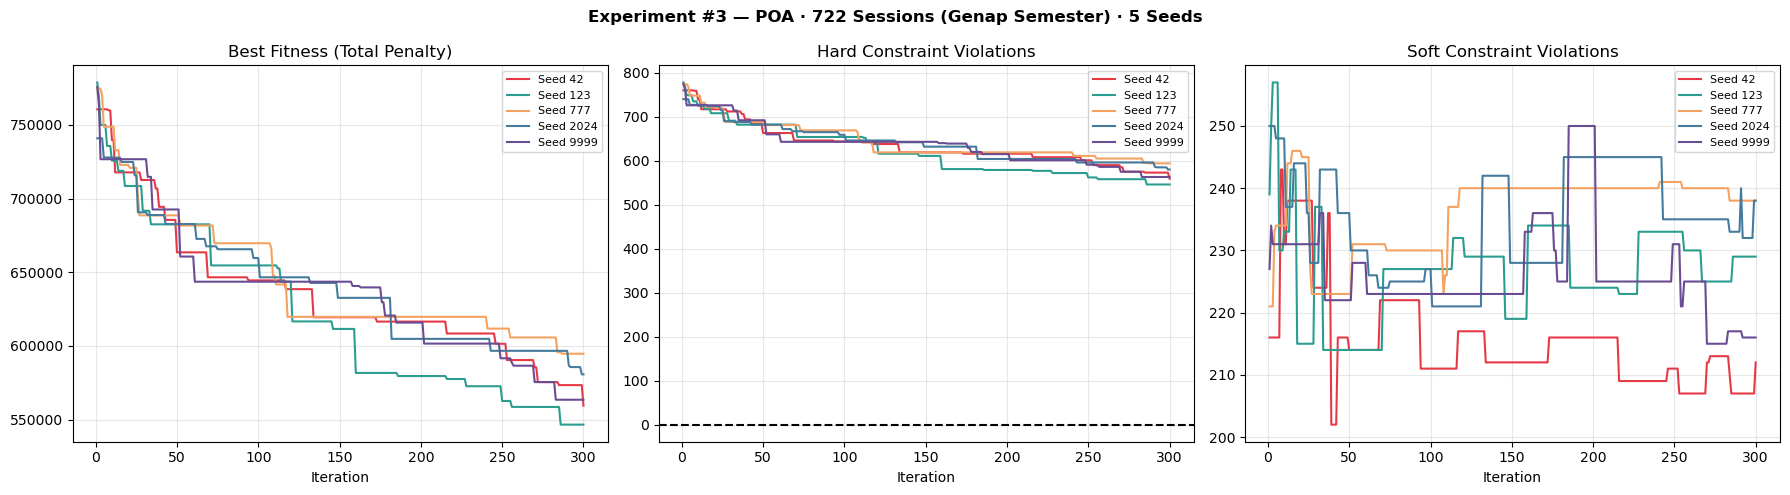

Convergence plot → poa_convergence_exp3_v3.png


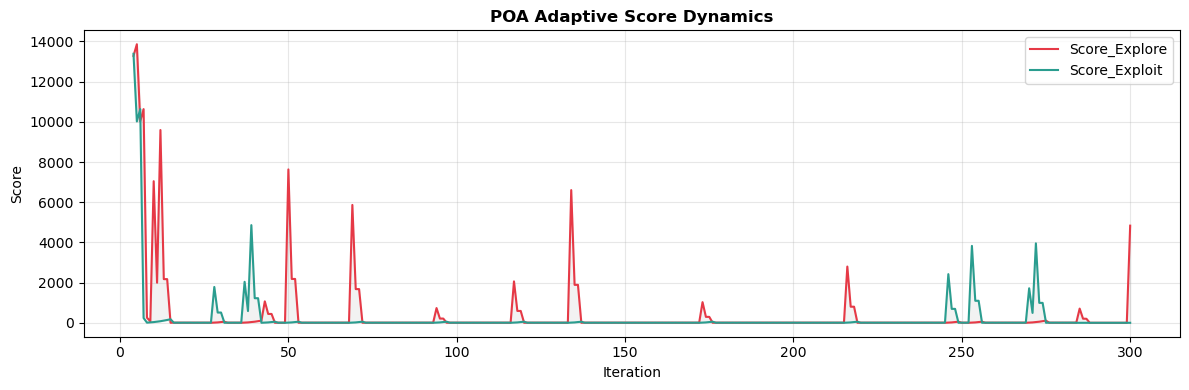

Score dynamics → poa_scores_v3.png

Best timetable → best_timetable_exp3_v3.csv
  seed=123  hard=546  soft=229

Results summary:
 seed  best_fitness  hard_viol  soft_viol  n_iterations  runtime_s  solved
   42      559460.0        559        212           300     246.54   False
  123      546630.0        546        229           300     250.43   False
  777      594720.0        594        238           300     242.92   False
 2024      580720.0        580        238           300     242.43   False
 9999      563500.0        563        216           300     234.27   False
Mean fitness : 569,006
Solved       : 0/5


In [15]:
# ─────────────────────────────────────────────────────────────
# Cell 13 ▸ Run the POA Algorithm
# ─────────────────────────────────────────────────────────────

POA_CONFIG = dict(n_pop=30, max_iter=300, verbose=True)

print("=" * 65)
print(f"EXPERIMENT #3 — POA Fully-Random Init")
print(f"Scheduling {n_sessions} class sessions (Genap semester)")
print("=" * 65)

print("\n>>> MAIN RUN  (seed=42) ...")
result = run_poa(**POA_CONFIG, seed=42)

# ── Decode best schedule ──────────────────────────────────────
best_asgn = decode_solution(result["best_vec"])
df_best   = pd.DataFrame(best_asgn)

print("\n" + "=" * 65)
print("BEST SCHEDULE — SUMMARY")
print("=" * 65)
print(f"Sessions scheduled  : {len(df_best)}")
print(f"  Theory            : {(df_best['session_type']=='Theory').sum()}")
print(f"  Practicum         : {(df_best['session_type']=='Practicum').sum()}")
print(f"Hard violations     : {result['best_hard']}")
print(f"Soft violations     : {result['best_soft']}")
print(f"Total penalty       : {result['best_fitness']:,.0f}")
print(f"Runtime             : {result['elapsed_s']:.1f} s")

print("\nConstraint breakdown:")
_, _, _, det = evaluate_fitness(result["best_vec"])
for k, v in det.items():
    w  = {"H1":W_H1,"H2":W_H2,"H3":W_H3,"H4":W_H4,"S1":W_S1,"S2":W_S2}[k[:2]]
    ok = "✓" if v == 0 else "✗"
    print(f"  {ok} {k:28s}: {v:5d}  (×{w:5d} = {v*w:8,.0f})")

print("\nSample schedule (first 15 sessions):")
print(df_best[["session_idx","teacher_id","course_name","room_id",
               "day","start_slot","end_slot","session_type"]].head(15).to_string(index=False))

# ── 5-seed robustness test ────────────────────────────────────
SEEDS   = [42, 123, 777, 2024, 9999]
results = [result]
print("\n" + "=" * 65)
print("ROBUSTNESS — 5 independent seeds")
print("=" * 65)
print(f"{'Seed':>6}  {'Fitness':>10}  {'Hard':>6}  {'Soft':>6}  "
      f"{'Iters':>6}  {'Time(s)':>8}  {'Solved':>7}")
print("─" * 60)
print(f"{42:>6}  {result['best_fitness']:>10,.0f}  {result['best_hard']:>6}  "
      f"{result['best_soft']:>6}  {result['n_iterations']:>6}  "
      f"{result['elapsed_s']:>8.1f}  {'YES' if result['best_hard']==0 else 'no':>7}")

for s in SEEDS[1:]:
    r = run_poa(**{**POA_CONFIG, "verbose":False}, seed=s)
    results.append(r)
    print(f"{s:>6}  {r['best_fitness']:>10,.0f}  {r['best_hard']:>6}  "
          f"{r['best_soft']:>6}  {r['n_iterations']:>6}  "
          f"{r['elapsed_s']:>8.1f}  {'YES' if r['best_hard']==0 else 'no':>7}")

# ── Phase analysis ────────────────────────────────────────────
hist = result["history"]
print("\n" + "=" * 65)
print("ADAPTIVE PHASE SELECTION  (main run)")
print("=" * 65)
print(f"  Unexperienced : {sum(1 for h in hist if h['phase']=='UNEXPERIENCED')} iters")
print(f"  EXPLORE       : {sum(1 for h in hist if h['phase']=='EXPLORE')} iters")
print(f"  EXPLOIT       : {sum(1 for h in hist if h['phase']=='EXPLOIT')} iters")

# ── Convergence plot ──────────────────────────────────────────
colors = ["#e63946","#2a9d8f","#f4a261","#457b9d","#6a4c93"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    f"Experiment #3 — POA · {n_sessions} Sessions (Genap Semester) · 5 Seeds",
    fontsize=12, fontweight="bold"
)
for r, col, s in zip(results, colors, SEEDS):
    iters = [h["iteration"]    for h in r["history"]]
    fits  = [h["best_fitness"] for h in r["history"]]
    hard  = [h["best_hard"]    for h in r["history"]]
    soft  = [h["best_soft"]    for h in r["history"]]
    lbl   = f"Seed {s}"
    axes[0].plot(iters, fits, color=col, lw=1.5, label=lbl)
    axes[1].plot(iters, hard, color=col, lw=1.5, label=lbl)
    axes[2].plot(iters, soft, color=col, lw=1.5, label=lbl)

axes[0].set_title("Best Fitness (Total Penalty)")
axes[1].set_title("Hard Constraint Violations")
axes[1].axhline(0, color="k", lw=1.5, ls="--")
axes[2].set_title("Soft Constraint Violations")
for ax in axes:
    ax.set_xlabel("Iteration"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("poa_convergence_exp3_v3.png", dpi=150, bbox_inches="tight")
plt.show()
print("Convergence plot → poa_convergence_exp3_v3.png")

# ── Score dynamics ────────────────────────────────────────────
exp_h = [h for h in hist if "Score_Explore" in h]
if exp_h:
    fig2, ax2 = plt.subplots(figsize=(12, 4))
    iters_e  = [h["iteration"]     for h in exp_h]
    se_vals  = [h["Score_Explore"] for h in exp_h]
    sx_vals  = [h["Score_Exploit"] for h in exp_h]
    ax2.plot(iters_e, se_vals, color="#e63946", lw=1.5, label="Score_Explore")
    ax2.plot(iters_e, sx_vals, color="#2a9d8f", lw=1.5, label="Score_Exploit")
    ax2.fill_between(iters_e,
        [max(a,b) for a,b in zip(se_vals,sx_vals)],
        [min(a,b) for a,b in zip(se_vals,sx_vals)],
        alpha=0.1, color="gray")
    ax2.set_title("POA Adaptive Score Dynamics", fontweight="bold")
    ax2.set_xlabel("Iteration"); ax2.set_ylabel("Score")
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("poa_scores_v3.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Score dynamics → poa_scores_v3.png")

# ── Export results ────────────────────────────────────────────
best_r = min(results, key=lambda r:(r["best_hard"], r["best_fitness"]))
pd.DataFrame(decode_solution(best_r["best_vec"])).to_csv(
    "best_timetable_exp3_v3.csv", index=False)
print(f"\nBest timetable → best_timetable_exp3_v3.csv")
print(f"  seed={best_r['seed']}  hard={best_r['best_hard']}  soft={best_r['best_soft']}")

df_res = pd.DataFrame([{
    "seed":r["seed"],"best_fitness":r["best_fitness"],"hard_viol":r["best_hard"],
    "soft_viol":r["best_soft"],"n_iterations":r["n_iterations"],
    "runtime_s":round(r["elapsed_s"],2),"solved":r["best_hard"]==0,
} for r in results])
print("\nResults summary:")
print(df_res.to_string(index=False))
print(f"Mean fitness : {df_res['best_fitness'].mean():,.0f}")
print(f"Solved       : {df_res['solved'].sum()}/{len(df_res)}")
